# Part II — Numbers and Mathematical Foundations

> *Chapters 21–50 | Prerequisites: Part I (Mathematical Thinking)*

---

## What This Part Covers

Part I gave you the thinking tools: abstraction, modeling, logical structure, and the habit of exploring mathematically. Part II turns those tools toward their first real target — **numbers themselves**.

Numbers are not obvious. Most programmers interact with them daily without knowing what they actually are, where they came from, or why they behave the way they do. This Part fixes that.

You will work through:

- The **taxonomy of numbers**: natural, integer, rational, irrational, real, complex — each a distinct mathematical universe with its own rules
- **Prime numbers and factorization**: the atomic structure of the integers
- **Modular arithmetic**: the mathematics of cycles, clocks, and cryptography
- **Exponents and logarithms**: the tools that tame exponential growth and compress vast scales
- **Floating-point representation**: why computers lie about numbers, and how to catch them
- **Numerical stability**: what breaks in computation and how to design around it
- **Orders of magnitude**: the habit of thinking in powers of ten

Two projects close the Part: a population growth simulation and a floating-point exploration — both revealing.

---

## The Mental Shift Required

In Part I, you reasoned *about* mathematics. In Part II, you reason *with* the raw material.

The shift is this: **stop treating numbers as given and start treating them as constructed objects with structure you can probe computationally.**

When you write `0.1 + 0.2` in Python and get `0.30000000000000004`, that is not a bug — it is a consequence of how real numbers are approximated in finite binary storage. When you ask why RSA encryption works, the answer lives in modular arithmetic. When you ask why neural network weights are initialized to small values near zero, the answer involves numerical stability and the behavior of exponentials.

Numbers have architecture. This Part exposes it.

---

## Map of This Part

```
Number Systems (ch021–027)
  ├── Natural → Integer → Rational → Irrational → Real → Complex
  └── Each extends the previous, adding closure under new operations

Prime Structure (ch028–030)
  ├── Primes as atoms of multiplication
  └── Factorization algorithms and number patterns

Modular Arithmetic (ch031–033)
  ├── Arithmetic on cycles
  └── Programming applications: hashing, scheduling, cryptography

Ratios, Fractions, Scientific Notation (ch034–036)
  └── Representation and scale

Floating-Point and Precision (ch037–040)
  ├── IEEE 754 representation
  ├── Catastrophic cancellation and error accumulation
  └── Project: Floating Point Exploration

Exponents and Logarithms (ch041–046)
  ├── Exponential growth and its universality
  ├── Logarithms as the inverse operation
  └── Log scales, computational logarithms

Growth and Scale (ch047–048)
  └── Comparing growth rates, orders of magnitude

Numerical Experiments (ch049)
  └── Structured exploration of growth behaviors

Projects (ch049–050)
  ├── Population Growth Simulation
  └── Floating Point Exploration
```

---

## Prerequisites from Part I

- **ch001–004**: Mathematical thinking, abstraction, modeling mindset
- **ch006**: Discrete vs continuous thinking — directly relevant when distinguishing integers from reals
- **ch007**: Computational experiments — the same methodology applies here
- **ch009**: Mathematical notation — you will read and write number-theoretic expressions
- **ch017–018**: From real-world problem to mathematical model — used in both projects

---

## Motivating Problem: A Problem You Cannot Yet Solve

Run the cell below. It will produce surprising output. By the end of Part II, you will understand every line of what follows — and more importantly, *why* each result is what it is.

=== Puzzle 1: Floating Point ===
0.1 + 0.2 = 0.30000000000000004
0.1 + 0.2 == 0.3: False
Difference: 5.55e-17

=== Puzzle 2: Catastrophic Cancellation ===
(1e15 + 1) - 1e15 = 1.0

=== Puzzle 3: Exponential Growth ===
Doublings in 24h: 72
Bacteria count:   4.722e+21
Earth population: 7.900e+09
Ratio to humans:  5.98e+11

=== Puzzle 4: Log Scale ===
Value         Log10
           1  0.0
          10  1.0
         100  2.0
       1,000  3.0
   1,000,000  6.0
1,000,000,000  9.0

=== Puzzle 5: Modular Arithmetic ===
2^16 mod 17 = 1
3^16 mod 17 = 1
5^16 mod 17 = 1
7^16 mod 17 = 1


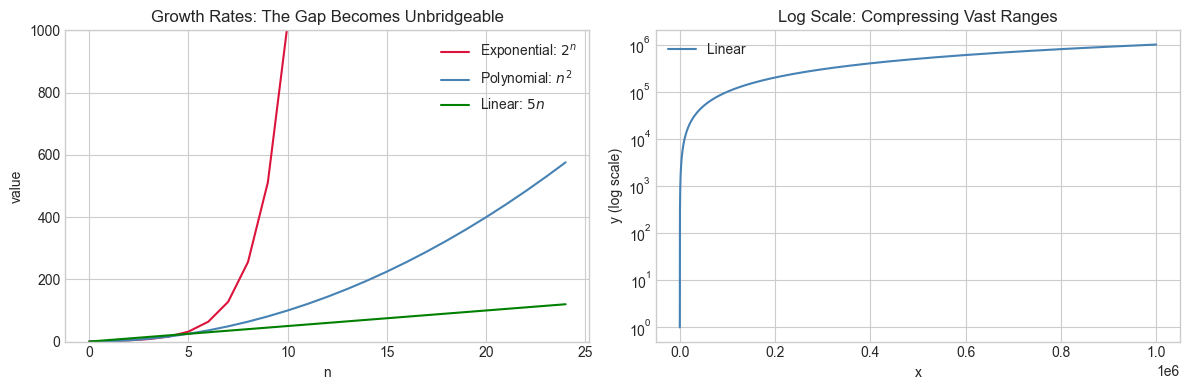


By the end of Part II, every result above will make complete sense.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# -------------------------------------------------------
# PUZZLE 1: Why does arithmetic lie?
# -------------------------------------------------------
print("=== Puzzle 1: Floating Point ===")
a = 0.1 + 0.2
print(f"0.1 + 0.2 = {a}")                    # Not 0.3
print(f"0.1 + 0.2 == 0.3: {a == 0.3}")       # False
print(f"Difference: {a - 0.3:.2e}")           # Not zero

# -------------------------------------------------------
# PUZZLE 2: Why do large computations lose precision?
# -------------------------------------------------------
print("\n=== Puzzle 2: Catastrophic Cancellation ===")
x = 1e15
result = (x + 1.0) - x
print(f"(1e15 + 1) - 1e15 = {result}")       # Should be 1.0

# -------------------------------------------------------
# PUZZLE 3: How fast does exponential growth consume the world?
# -------------------------------------------------------
print("\n=== Puzzle 3: Exponential Growth ===")
# Bacteria doubling every 20 minutes. Start with 1.
# After 24 hours, how many?
doublings = 24 * 3   # 3 doublings per hour
count = 2 ** doublings
print(f"Doublings in 24h: {doublings}")
print(f"Bacteria count:   {count:.3e}")
print(f"Earth population: {7.9e9:.3e}")
print(f"Ratio to humans:  {count / 7.9e9:.2e}")

# -------------------------------------------------------
# PUZZLE 4: Why is log useful for comparing growth?
# -------------------------------------------------------
print("\n=== Puzzle 4: Log Scale ===")
values = [1, 10, 100, 1_000, 1_000_000, 1_000_000_000]
print("Value         Log10")
for v in values:
    print(f"{v:>12,}  {np.log10(v):.1f}")

# -------------------------------------------------------
# PUZZLE 5: What makes primes special in computation?
# -------------------------------------------------------
print("\n=== Puzzle 5: Modular Arithmetic ===")
# Fermat's little theorem: a^(p-1) ≡ 1 (mod p) for prime p, gcd(a,p)=1
p = 17  # prime
for a in [2, 3, 5, 7]:
    result = pow(a, p - 1, p)  # Python's efficient modular exponentiation
    print(f"{a}^{p-1} mod {p} = {result}")

# -------------------------------------------------------
# VISUALIZATION: All puzzles summarized on one plot
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Exponential vs linear growth
ax = axes[0]
n = np.arange(0, 25)
ax.plot(n, 2**n, label='Exponential: $2^n$', color='crimson')
ax.plot(n, n**2, label='Polynomial: $n^2$', color='steelblue')
ax.plot(n, n * 5, label='Linear: $5n$', color='green')
ax.set_xlabel('n')
ax.set_ylabel('value')
ax.set_title('Growth Rates: The Gap Becomes Unbridgeable')
ax.set_ylim(0, 1000)
ax.legend()

# Plot 2: Log scale reveals structure
ax = axes[1]
x = np.linspace(1, 1e6, 10000)
ax.semilogy(x, x, label='Linear', color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('y (log scale)')
ax.set_title('Log Scale: Compressing Vast Ranges')
ax.legend()

plt.tight_layout()
plt.show()

print("\nBy the end of Part II, every result above will make complete sense.")

---

## How to Work Through This Part

**Do not skip the number system chapters (ch021–027).** They are short, but they build the precise vocabulary you need for everything that follows. Programmers who skip them accumulate confusion that compounds over hundreds of chapters.

**Pay extra attention to ch037–039 (floating-point).** This is the most practically dangerous topic in the Part. More bugs in numerical code come from floating-point misunderstanding than from any other single source.

**The two projects (ch049, ch050) are not optional.** They are where the Part's concepts crystallize into working systems. Do them in order.

---

*Part II begins with ch021 — The History of Numbers.*